## 2개 층 신경망
- 하나의 층에 여러 개의 뉴런을 사용하면 한번에 여러 특성을 뉴런에 전달 가능
- $\begin{bmatrix} x_1 & \cdots & x_n \end{bmatrix} \begin{bmatrix}  w_{1 1} & w_{1 2} \\ \vdots & \vdots \\ w_{n 1} & w_{n 2} \end{bmatrix} + \begin{bmatrix} b_1 & b_2 \end{bmatrix} = \begin{bmatrix} z_1 & z_2 \end{bmatrix}$
- 각 뉴런에서 나온 출력을 모아야 이진 분류에 사용 가능
- <img src="img/zj.png" width="400"/>

## 다층 신경망
- <img src="img/zk.png" width="400"/>
- 한 층의 활성화 함수는 모두 같아야함. 
- 모든 뉴런이 연결되어 있으므로 완전 연결 신경망이라고 부름


## 다층 신경망의 경사하강법
- <img src="img/zl.png" width="400"/>
- 오른쪽 출력층에서 왼쪽 은닉층 방향으로 미분
- 가중치에 대한 손실함수 미분  
<img src="img/zm.png" width="800"/>  
$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial Z_2} \frac{\partial Z_2}{\partial A_1} \frac{\partial A_1}{\partial Z_1} \frac{\partial Z_1}{\partial W_1} = X^T \underbrace{(\underbrace{-(Y - A_2)W_2^T}_{\text{2층에서 전달된 오차}} \odot \underbrace{A_1 \odot (1 - A_1)}_{\text{1층 활성화 함수 미분}})}_{\text{1층까지 도달한 최종 오차 신호}}$$
$$\begin{bmatrix} a & b \\ c & d \end{bmatrix} \odot \begin{bmatrix} e & f \\ g & h \end{bmatrix} = \begin{bmatrix} a \cdot e & b \cdot f \\ c \cdot g & d \cdot h \end{bmatrix}$$
- 절편에 대한 손실함수 미분
$$\frac{\partial L}{\partial b_2} = \underbrace{\frac{\partial L}{\partial Z_2}}_{\text{오차 신호}} \cdot \underbrace{\frac{\partial Z_2}{\partial b_2}}_{1} = 1^T (-(Y - A_2))$$
$$1^T = [1, 1, \ldots, 1]$$
$$\frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial A_1} \cdot \frac{\partial A_1}{\partial Z_1} \cdot \underbrace{\frac{\partial Z_1}{\partial b_1}}_{1}$$
$$\frac{\partial L}{\partial b_1} = 1^T (\underbrace{-(Y - A_2)W_2^T}_{\text{2층에서 온 신호}} \odot \underbrace{A_1 \odot (1 - A_1)}_{\text{활성화 함수 미분}})$$


455 114
364 91
0.978021978021978


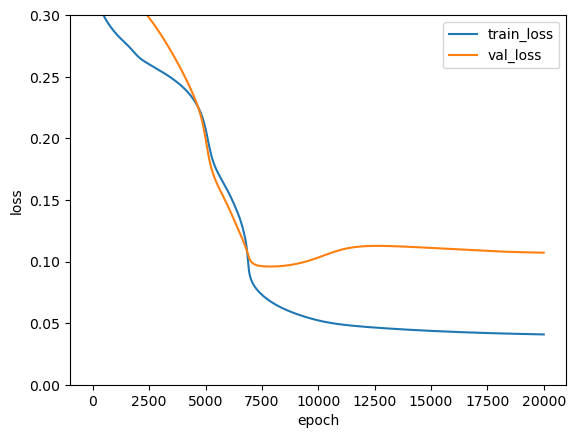

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

class SingleLayer:
    def __init__(self, learning_rate=0.1, l1=0, l2=0):
        self.w = None
        self.b = None
        self.losses = []
        self.val_losses = []
        self.w_history = []
        self.lr = learning_rate

        self.l1 = l1 # L1 추가
        self.l2 = l2 # L2 추가

    def forpass(self, x):
        z = np.dot(x, self.w) + self.b
        return z
    
    def backprop(self, x, err):
        m = len(x)
        w_grad = np.dot(x.T, err) / m
        b_grad = np.sum(err) / m
        return w_grad, b_grad
    
    def activation(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a
    
    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        y = y.reshape(-1, 1) # 열 벡터로 바꿈(-1은 자동)
        y_val = y_val.reshape(-1, 1)
        m = len(x)

        self.w = np.ones((x.shape[1], 1))
        self.b = 0
        self.w_history.append(self.w.copy())

        for i in range(epochs):

            z = self.forpass(x)
            a = self.activation(z)
            err = -(y - a) # 오차 계산(샘플 별, y, z 모두 n*1 행렬 -> err는 n*1행렬 )

            w_grad, b_grad = self.backprop(x, err)
            w_grad += (self.l1 * np.sign(self.w) + self.l2 * self.w) / m

            self.w -= self.lr * w_grad
            self.b -= self.lr * b_grad

            self.w_history.append(self.w.copy())

            a = np.clip(a, 1e-10, 1-1e-10)

            loss = np.sum(-(y*np.log(a) + (1-y)*np.log(1-a)))

            self.losses.append((loss + self.reg_loss()) / m)
            self.update_val_loss(x_val, y_val)

    
    def predict(self, x):
        z = self.forpass(x)
        return z > 0
    
    def score(self, x, y):
        return np.mean(self.predict(x) == y.reshape(-1, 1))

    def reg_loss(self):
        return self.l1 * np.sum(np.abs(self.w)) + self.l2 / 2*np.sum(self.w**2) # L1, L2 계산

    def update_val_loss(self, x_val, y_val):

        z = self.forpass(x_val)
        a = self.activation(z)
        a = np.clip(a, 1e-10, 1-1e-10)

        val_loss = np.sum(-(y_val*np.log(a) + (1-y_val)*np.log(1-a)))
        self.val_losses.append((val_loss + self.reg_loss()) / len(y_val))

# 2개 층 신경망 구현
class DualLayer(SingleLayer): # SingleLayer 상속
    def __init__(self, units=10, learning_rate=0.1, l1=0, l2=0):
        self.units = units # 은닉층 뉴런 갯수
        self.w1 = None # 은닉층 가중치
        self.b1 = None # 은닉층 절편
        self.w2 = None # 출력층 가중치
        self.b2 = None # 출력층 절편
        self.a1 = None # 은닉층 활성화 출력
        self.losses = [] # 훈련 손실
        self.val_losses = [] # 검증 손실
        self.lr = learning_rate # 학습률
        self.l1 = l1 # L1 규제
        self.l2 = l2 # L2 규제

    def forpass(self, x): # SingleLayer forpass 매소드 오버라이드
        z1 = np.dot(x, self.w1) + self.b1 # 첫번째 층의 선형 계산
        self.a1 = self.activation(z1) # 활성화 함수 적용
        z2 = np.dot(self.a1, self.w2) + self.b2 # 두번째 층 선형 계산
        return z2

    def backprop(self, x, err):

        m = len(x) # 샘플 개수
        # 출력층 가중치/절편에 대한 그래디언트 계산
        w2_grad = np.dot(self.a1.T, err) / m
        b2_grad = np.sum(err) / m

        # 시그모이드 함수까지 그래디언트 계산
        err_to_hidden = np.dot(err, self.w2.T,) * self.a1 * (1 - self.a1)

        # 은닉층 가중치/절편에 대한 그래디언트 계산
        w1_grad = np.dot(x.T, err_to_hidden) / m
        b1_grad = np.sum(err_to_hidden, axis=0) / m
        return w1_grad, b1_grad, w2_grad, b2_grad

    def init_weights(self, n_features):
        self.w1 = np.ones((n_features, self.units)) # (특성 갯수, 은닉층 크기)
        self.b1 = np.zeros(self.units) # 은닉층의 크기
        self.w2 = np.ones((self.units, 1)) # (은닉층의 크기, 1)
        self.b2 = 0

    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        y = y.reshape(-1, 1) # 열 벡터로 변환
        y_val = y_val.reshape(-1, 1)
        m = len(x) # 샘플 갯수 저장
        self.init_weights(x.shape[1])
        # epochs만큼 반복합니다
        for i in range(epochs):
            a = self.traning(x, y, m)
            a = np.clip(a, 1e-10, 1-1e-10) # 안전한 로그 계산을 위한 클리핑
            # 로그 손실 추가
            loss = np.sum(-(y*np.log(a) + (1-y)*np.log(1-a)))
            self.losses.append((loss + self.reg_loss()) / m)
            # 검증 세트에 대한 손실 계산
            self.update_val_loss(x_val, y_val)
    
    def traning(self, x, y, m):
        z = self.forpass(x) # 정방향 계산 수행
        a = self.activation(z) # 활성화 함수 적용
        err = -(y - a)
        # 오차를 역전파하여 그래디언트 계산
        w1_grad, b1_grad, w2_grad, b2_grad = self.backprop(x, err)

        # 그래디언트에 패널티 항의 미분 값 더함
        w1_grad += (self.l1 * np.sign(self.w1) + self.l2 * self.w1) / m
        w2_grad += ( self.l1 * np.sign(self.w2) + self.l2 * self.w2) / m
        
        # 은닉층의 가중치와 절편 업데이트
        self.w1 -= self.lr * w1_grad
        self.b1 -= self.lr * b1_grad

        # 출력층 가중치와 절편 업데이트
        self.w2 -= self.lr * w2_grad
        self.b2 -= self.lr * b2_grad
        return a

    def reg_loss(self):
        # 은닉층과 출력층의 가중치에 규제 적용
        return self.l1 * (np.sum(np.abs(self.w1)) + np.sum(np.abs(self.w2))) + \
                self.l2 / 2 * (np.sum(self.w1 ** 2) + np.sum(self.w2**2))

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))

x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(len(x_train), len(x_val))


scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_val_scaled = scaler.transform(x_val)

dual_layer = DualLayer(l2=0.01)
dual_layer.fit(x_train_scaled, y_train, x_val=x_val_scaled, y_val=y_val, epochs=20000)

print(dual_layer.score(x_val_scaled, y_val))

plt.ylim(0, 0.3)
plt.plot(dual_layer.losses)
plt.plot(dual_layer.val_losses)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

0.978021978021978


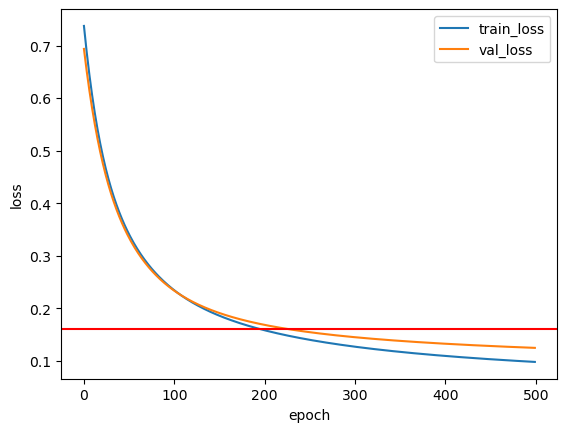

In [10]:
# 가중치 초기화
class RandomInitNetwork(DualLayer):
    def init_weights(self, n_features):
        np.random.seed(42)
        # 가중치를 1로 초기화 하는 것이 아닌 평균 0, 표준편차 1의 정규분포를 따르는 랜덤 난수로 초기화
        self.w1 = np.random.normal(0, 1, (n_features, self.units))
        self.b1 = np.zeros(self.units)
        self.w2 = np.random.normal(0, 1, (self.units, 1))
        self.b2 = 0

random_init_net = RandomInitNetwork(l2=0.01)
random_init_net.fit(x_train_scaled, y_train, x_val=x_val_scaled, y_val=y_val, epochs=500)

print(random_init_net.score(x_val_scaled, y_val))

plt.plot(random_init_net.losses)
plt.plot(random_init_net.val_losses)

plt.axhline(y=0.16, color='r')

plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

455 114
364 91
0.978021978021978


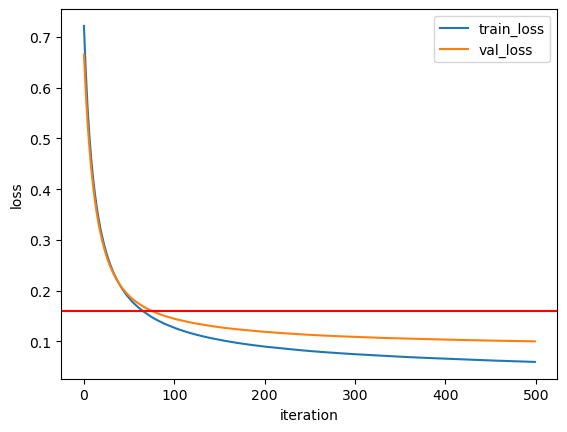

In [9]:
# 미니 배치 구현  
class MinibatchNetwork(RandomInitNetwork):

    def __init__(self, units=10, batch_size=32, learning_rate=0.1, l1=0, l2=0):
        super().__init__(units, learning_rate, l1, l2)
        self.batch_size = batch_size

    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        y_val = y_val.reshape(-1, 1)
        self.init_weights(x.shape[1])
        np.random.seed(42)
        for i in range(epochs):

            loss = 0

            for x_batch, y_batch in self.gen_batch(x, y):
                y_batch = y_batch.reshape(-1, 1)
                m = len(x_batch)
                a = self.traning(x_batch, y_batch, m)
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += np.sum(-(y_batch*np.log(a) + (1-y_batch)*np.log(1-a)))

            self.losses.append((loss + self.reg_loss()) / len(x))
            self.update_val_loss(x_val, y_val)
 
    def gen_batch(self, x, y):
        length = len(x)
        bins = length // self.batch_size
        if length % self.batch_size:
            bins += 1 # 나누어 떨어지지 않을때(length%self.batch_size != 0)
        indexes = np.random.permutation(np.arange(len(x)))
        x = x[indexes]
        y = y[indexes]
        for i in range(bins):
            start = self.batch_size * i
            end = self.batch_size * (i + 1)
            yield x[start:end], y[start:end]

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))

x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(len(x_train), len(x_val))

scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_val_scaled = scaler.transform(x_val)

minibatch_net = MinibatchNetwork(l2=0.01, batch_size=128)
minibatch_net.fit(x_train_scaled, y_train, x_val=x_val_scaled, y_val=y_val, epochs=500)

print(minibatch_net.score(x_val_scaled, y_val))

plt.plot(minibatch_net.losses)
plt.plot(minibatch_net.val_losses)

plt.axhline(y=0.16, color='r')

plt.ylabel('loss')
plt.xlabel('iteration')
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [ ]:
# Sci-kit Learn 미니배치

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))

x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(len(x_train), len(x_val))

scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_val_scaled = scaler.transform(x_val)

mlp = MLPClassifier(hidden_layer_sizes=(10, ), activation='logistic', solver='sgd', alpha=0.01, batch_size=32, learning_rate_init=0.1, max_iter=500)

mlp.fit(x_train_scaled, y_train)
print(mlp.score(x_val_scaled, y_val))

455 114
364 91
0.989010989010989
